In [1]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_parquet("../data/raw/complaints.parquet")
df["date_received"] = pd.to_datetime(df["date_received"])
df.shape

(75000, 8)

## Class balance by product

In [2]:
counts = df["product"].value_counts()
share = (counts / len(df) * 100).round(1)
pd.DataFrame({"count": counts, "pct": share})

,count,pct
product,,
"Credit reporting, credit repair services, or other personal consumer reports",30025,40.0
Credit reporting or other personal consumer reports,13520,18.0
Debt collection,9871,13.2
Mortgage,4475,6.0
Credit card or prepaid card,4033,5.4
Checking or savings account,3638,4.9
Credit card,1798,2.4
Student loan,1695,2.3
"Money transfer, virtual currency, or money service",1553,2.1


## Narrative length distribution

count    75000.000000
mean       181.379893
std        232.269165
min          1.000000
25%         61.000000
50%        118.000000
75%        216.000000
max       5714.000000
Name: narrative, dtype: float64


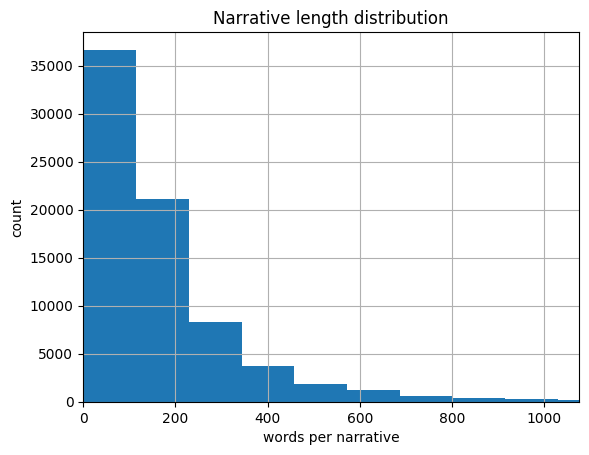

In [3]:
word_count = df["narrative"].str.split().str.len()
print(word_count.describe())

word_count.hist(bins=50)
plt.xlim(0, word_count.quantile(0.99))
plt.xlabel("words per narrative")
plt.ylabel("count")
plt.title("Narrative length distribution")
plt.show()

## How much text is `XXXX` redaction

In [4]:
xxxx_count = df["narrative"].str.count(r"XXXX")
redaction_share = xxxx_count / word_count

print("narratives with at least one XXXX:", (xxxx_count > 0).mean().round(3))
print("mean share of words that are XXXX:", redaction_share.mean().round(3))

narratives with at least one XXXX: 0.76
mean share of words that are XXXX: 0.078


## Complaints per year

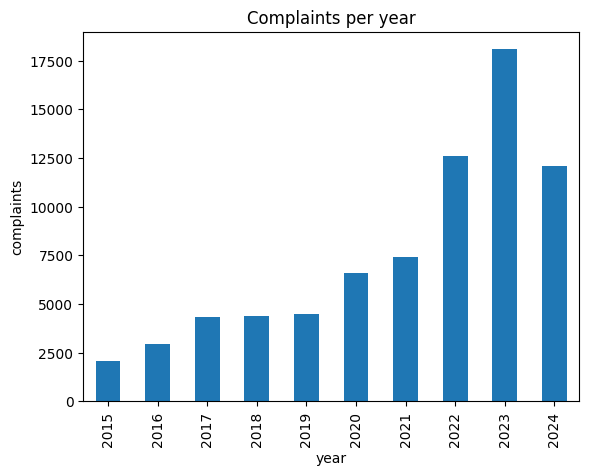

In [5]:
by_year = df["date_received"].dt.year.value_counts().sort_index()
by_year.plot(kind="bar")
plt.xlabel("year")
plt.ylabel("complaints")
plt.title("Complaints per year")
plt.show()